In [1]:
from transformers import (
    CLIPTokenizer,
    CLIPTextModel,
    CLIPImageProcessor,
    CLIPVisionModel,
    DataCollatorWithPadding,
)
from datasets import load_dataset, concatenate_datasets
import torch
from torch.utils.data import DataLoader
from PIL import Image, ImageDraw
import numpy as np
from torchvision import transforms

In [2]:
MODEL_NAME = "openai/clip-vit-base-patch32"

In [3]:
ds = load_dataset("lmms-lab/RefCOCO")
ds

DatasetDict({
    val: Dataset({
        features: ['question_id', 'image', 'question', 'answer', 'segmentation', 'bbox', 'iscrowd', 'file_name'],
        num_rows: 8811
    })
    test: Dataset({
        features: ['question_id', 'image', 'question', 'answer', 'segmentation', 'bbox', 'iscrowd', 'file_name'],
        num_rows: 5000
    })
    testA: Dataset({
        features: ['question_id', 'image', 'question', 'answer', 'segmentation', 'bbox', 'iscrowd', 'file_name'],
        num_rows: 1975
    })
    testB: Dataset({
        features: ['question_id', 'image', 'question', 'answer', 'segmentation', 'bbox', 'iscrowd', 'file_name'],
        num_rows: 1810
    })
})

In [5]:
combined_ds = concatenate_datasets([ds["val"], ds["test"], ds["testA"], ds["testB"]])
combined_ds

Dataset({
    features: ['question_id', 'image', 'question', 'answer', 'segmentation', 'bbox', 'iscrowd', 'file_name'],
    num_rows: 17596
})

In [7]:
# del text_model
# del vision_model

In [8]:
combined_ds[0]

{'question_id': '1537681',
 'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=640x428>,
 'question': 'Please carefully observe the area circled in the image and come up with a caption for the area.',
 'answer': ['bowl behind the others can only see part',
  'Dish in top right corner',
  'White dish in the top right corner.',
  'white pot upper right corner'],
 'segmentation': [468.29998779296875,
  2.8299999237060547,
  471.17999267578125,
  46.0099983215332,
  473.1000061035156,
  83.44000244140625,
  521.0900268554688,
  107.43000030517578,
  580.5800170898438,
  117.02999877929688,
  640.0,
  106.47000122070312,
  640.0,
  104.55000305175781,
  640.0,
  0.9100000262260437],
 'bbox': [468.29998779296875,
  0.9100000262260437,
  171.6999969482422,
  116.12000274658203],
 'iscrowd': 0,
 'file_name': 'COCO_train2014_000000580957_4.jpg'}

In [80]:
tokenizer = CLIPTokenizer.from_pretrained(MODEL_NAME)
processor = CLIPImageProcessor.from_pretrained(MODEL_NAME)
to_tensor = transforms.ToTensor()

In [10]:
sample_image = combined_ds[0]["image"]

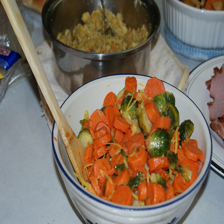

In [ ]:
sample_image.resize((224, 224))

In [12]:
pixel_values = processor(sample_image)["pixel_values"][0]

In [13]:
processor(sample_image)["pixel_values"]

[tensor([[[-0.4784, -0.4492, -0.4054,  ..., -0.6098, -0.4784, -0.3908],
          [-0.4054, -0.3908, -0.3324,  ..., -0.5222, -0.3908, -0.3324],
          [-0.3324, -0.3324, -0.3178,  ..., -0.3908, -0.2594, -0.2886],
          ...,
          [ 0.4851,  0.4997,  0.4997,  ...,  0.5581,  0.5435,  0.5289],
          [ 0.4705,  0.4559,  0.5289,  ...,  0.5873,  0.5581,  0.5581],
          [ 0.4705,  0.5143,  0.4851,  ...,  0.5435,  0.5581,  0.5581]],
 
         [[-1.0767, -1.0617, -1.0167,  ..., -0.9867, -0.9267, -0.9567],
          [-0.9867, -0.9867, -0.9717,  ..., -0.9717, -0.9567, -0.9567],
          [-0.9267, -0.9117, -0.8967,  ..., -0.9267, -0.9117, -0.9417],
          ...,
          [ 0.7692,  0.7842,  0.8142,  ...,  0.8743,  0.8743,  0.8893],
          [ 0.7692,  0.7392,  0.8292,  ...,  0.8743,  0.8743,  0.8593],
          [ 0.7992,  0.8292,  0.7992,  ...,  0.8442,  0.8743,  0.8743]],
 
         [[-1.2669, -1.3096, -1.2954,  ..., -1.2385, -1.2954, -1.3949],
          [-1.2100, -1.2527,

In [14]:
pixel_values.numpy().shape

(3, 224, 224)

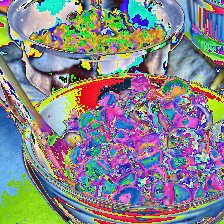

In [15]:
transforms.ToPILImage("RGB")(pixel_values)

In [16]:
combined_ds[0]["image"].size

(640, 428)

In [17]:
combined_ds[0]["segmentation"]

[468.29998779296875,
 2.8299999237060547,
 471.17999267578125,
 46.0099983215332,
 473.1000061035156,
 83.44000244140625,
 521.0900268554688,
 107.43000030517578,
 580.5800170898438,
 117.02999877929688,
 640.0,
 106.47000122070312,
 640.0,
 104.55000305175781,
 640.0,
 0.9100000262260437]

In [18]:
seg_polygon = combined_ds[0]["segmentation"]
[(seg_polygon[i * 2], seg_polygon[i * 2 + 1]) for i in range(len(seg_polygon) // 2)]

[(468.29998779296875, 2.8299999237060547),
 (471.17999267578125, 46.0099983215332),
 (473.1000061035156, 83.44000244140625),
 (521.0900268554688, 107.43000030517578),
 (580.5800170898438, 117.02999877929688),
 (640.0, 106.47000122070312),
 (640.0, 104.55000305175781),
 (640.0, 0.9100000262260437)]

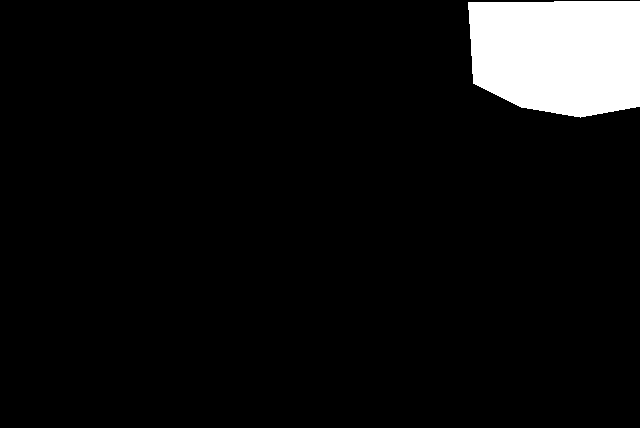

In [63]:
seg_polygon = combined_ds[0]["segmentation"]
img = Image.new("1", (640, 428))
draw = ImageDraw.Draw(img)
vertices = [
    (seg_polygon[i * 2], seg_polygon[i * 2 + 1]) for i in range(len(seg_polygon) // 2)
]
draw.polygon(vertices, 1)
img

In [ ]:
to_tensor = transforms.Compose(
    [
        transforms.ToTensor(),
    ]
)
yo = to_tensor(img.resize((224, 224))).bool()
yo

tensor([[[False, False, False,  ..., False, False, False],
         [False, False, False,  ...,  True,  True,  True],
         [False, False, False,  ...,  True,  True,  True],
         ...,
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False]]])

In [79]:
torch.logical_or(yo == 0, yo == 1).all()

tensor(True)

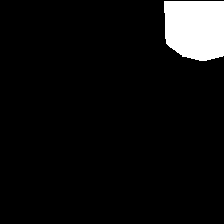

In [ ]:
img.resize((224, 224))

In [23]:
torch.from_numpy(np.array(img))

tensor([[False, False, False,  ..., False, False, False],
        [False, False, False,  ...,  True,  True,  True],
        [False, False, False,  ...,  True,  True,  True],
        ...,
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False]])

In [94]:
def process_data(batch):
    images = batch["image"]
    texts = [" . ".join(answers) for answers in batch["answer"]]
    polygons = batch["segmentation"]

    image_inputs = processor(images)
    text_inputs = tokenizer(texts, truncation=True)
    seg_masks = []

    for image, polygon in zip(images, polygons):
        mask_img = Image.new("1", image.size)
        img_draw = ImageDraw.Draw(mask_img)
        vertices = [
            (polygon[i * 2], polygon[i * 2 + 1]) for i in range(len(polygon) // 2)
        ]
        img_draw.polygon(vertices, fill=1)
        mask_tensor = to_tensor(mask_img.resize((224, 224))).bool()
        seg_masks.append(mask_tensor)

    return {
        "pixel_values": image_inputs["pixel_values"],
        "input_ids": text_inputs["input_ids"],
        "attention_mask": text_inputs["attention_mask"],
        "seg_masks": seg_masks,
    }

In [ ]:
torch.tensor([1, 1.1]).bool()

tensor([True, True])

In [26]:
combined_ds.column_names

['question_id',
 'image',
 'question',
 'answer',
 'segmentation',
 'bbox',
 'iscrowd',
 'file_name']

In [95]:
processed_ds = combined_ds.map(
    process_data,
    batched=True,
    remove_columns=combined_ds.column_names,
)

Map:   0%|          | 0/17596 [00:00<?, ? examples/s]

In [86]:
processed_ds

Dataset({
    features: ['pixel_values', 'input_ids', 'attention_mask', 'seg_masks'],
    num_rows: 17596
})

In [29]:
# processed_ds[0]["segmentation_mask"]

In [30]:
torch.tensor(processed_ds[0]["pixel_values"]).shape

torch.Size([3, 224, 224])

In [31]:
# type(processed_ds[0]["question_id"])

In [96]:
dataloader = DataLoader(
    processed_ds,
    batch_size=16,
    num_workers=2,
    collate_fn=DataCollatorWithPadding(tokenizer),
)

In [97]:
x = None
for batch in dataloader:
    x = batch
    break

In [98]:
x["pixel_values"].shape

torch.Size([16, 3, 224, 224])

In [99]:
x["input_ids"].shape

torch.Size([16, 31])

In [100]:
x["attention_mask"].shape

torch.Size([16, 31])

In [101]:
x["seg_masks"][0]

tensor([[[False, False, False,  ..., False, False, False],
         [False, False, False,  ...,  True,  True,  True],
         [False, False, False,  ...,  True,  True,  True],
         ...,
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False]]])

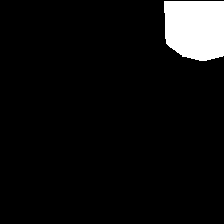

In [ ]:
transforms.ToPILImage()(x["seg_masks"][0].float())